
<div style="
  background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
  padding: 40px 30px;
  border-radius: 16px;
  overflow: hidden;
  color: #e0e0e0;
  font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif;
  margin-bottom: 20px;
  border: 1px solid #4a4a8a;
">
  <h1 style="
    text-align: center;
    font-size: 2.4em;
    margin-bottom: 6px;
    color: #00d4ff;
    text-shadow: 0 0 20px rgba(0,212,255,0.3);
    letter-spacing: 2px;
  ">🧊 FROZEN LAKE × Q-LEARNING</h1>
  <p style="
    text-align: center;
    font-size: 1.1em;
    color: #a0a0d0;
    margin-bottom: 25px;
    letter-spacing: 1px;
  ">Интерактивный учебный модуль по обучению с подкреплением</p>

  <div style="
    display: flex;
    justify-content: center;
    gap: 30px;
    font-size: 0.9em;
    color: #c0c0e0;
  ">
    <span>📐 Уравнение Беллмана</span>
    <span>🧠 Алгоритм Q-Learning</span>
    <span>🎮 Живая визуализация</span>
    <span>📊 Тепловые карты</span>
  </div>

  <hr style="border: 0; height: 1px; background: #4a4a8a; margin: 20px 0;">

  <p style="
    text-align: center;
    font-size: 0.85em;
    color: #7a7ab0;
  ">Автор модуля: CyberUnity Code · Платформа neon-unity-neural · 2025</p>
</div>



## 📑 Содержание модуля

| # | Раздел | Что изучаем |
|---|--------|-------------|
| 1 | 🌍 **Что такое обучение с подкреплением?** | Агент, среда, награда — базовые понятия |
| 2 | 🧊 **Среда Frozen Lake** | Правила игры и как устроена сетка |
| 3 | 📐 **Математика Q-Learning** | Уравнение Беллмана — пошагово и понятно |
| 4 | ⚙️ **Настройка окружения** | Установка библиотек и инициализация |
| 5 | 🏋️ **Обучение агента** | Цикл обучения с живым отображением прогресса |
| 6 | 📊 **Анализ результатов** | Графики метрик и тепловая карта Q-таблицы |
| 7 | 🎮 **Тестирование агента** | Смотрим, как обученный агент проходит озеро |
| 8 | 🧪 **Эксперименты** | Меняем параметры — наблюдаем эффект |

---



# 1. 🌍 Что такое обучение с подкреплением?

Представьте, что вы учите собаку новому трюку. Вы не можете объяснить собаке словами, что нужно делать. Вместо этого:

- Собака **пробует** разные действия (садится, ложится, даёт лапу...)
- Если действие **правильное** — вы даёте **лакомство** (награда! 🦴)
- Если действие **неправильное** — лакомства нет (нулевая награда)
- Через много попыток собака **запоминает**, какие действия приводят к награде

Именно так работает **обучение с подкреплением** (Reinforcement Learning, RL):

---

### 🔑 Четыре ключевых понятия

| Понятие | Что это | Пример (Frozen Lake) |
|---------|---------|---------------------|
| **Агент** (Agent) | Тот, кто учится | Наш персонаж на льду |
| **Среда** (Environment) | Мир, в котором агент действует | Замёрзшее озеро 4×4 |
| **Действие** (Action) | Что агент может сделать | Пойти влево / вправо / вверх / вниз |
| **Награда** (Reward) | Обратная связь от среды | +1 за достижение цели, 0 иначе |

---

### 🔄 Цикл обучения

Обучение происходит по кругу — снова и снова:

```
       ┌─────────────────────────────────┐
       │                                 │
       ▼                                 │
   ┌────────┐   действие    ┌────────┐   │
   │ АГЕНТ  │ ────────────► │ СРЕДА  │   │
   │        │               │        │   │
   │  «Что  │ ◄──────────── │ «Вот   │   │
   │  мне   │  новое        │  что   │   │
   │делать?»│  состояние    │  вышло»│   │
   │        │  + награда    │        │   │
   └────────┘               └────────┘   │
       │                                 │
       └─────────────────────────────────┘
```

**Цель агента** — научиться выбирать такие действия, которые приносят **максимальную суммарную награду** за всю игру.



# 2. 🧊 Среда Frozen Lake

**Frozen Lake** — это классическая задача из библиотеки Gymnasium (OpenAI Gym). Представьте замёрзшее озеро размером 4×4 клетки:

---

### 🗺️ Карта озера

```
  ┌─────┬─────┬─────┬─────┐
  │  S  │  F  │  F  │  F  │   S = Start    (Старт — начальная позиция)
  ├─────┼─────┼─────┼─────┤   F = Frozen   (Лёд — безопасная клетка)
  │  F  │  H  │  F  │  H  │   H = Hole     (Прорубь — провал! Конец игры)
  ├─────┼─────┼─────┼─────┤   G = Goal     (Цель — подарок! Награда +1)
  │  F  │  F  │  F  │  H  │
  ├─────┼─────┼─────┼─────┤
  │  H  │  F  │  F  │  G  │
  └─────┴─────┴─────┴─────┘
```

---

### 📏 Числа в среде

| Параметр | Значение | Пояснение |
|----------|----------|-----------|
| **Количество состояний** | 16 | Клетки с номерами 0..15 (4×4 сетка) |
| **Количество действий** | 4 | ← Влево (0), ↓ Вниз (1), → Вправо (2), ↑ Вверх (3) |
| **Награда за цель** | +1.0 | Агент дошёл до клетки G |
| **Награда за прорубь** | 0.0 | Агент упал — эпизод окончен |
| **Награда за шаг** | 0.0 | Простое перемещение ничего не даёт |

---

### ❄️ Скользкий лёд (is_slippery)

В стандартной версии Frozen Lake лёд **скользкий**: когда агент выбирает направление, он с вероятностью **1/3** двигается туда, куда хотел, и с вероятностью **1/3** — в каждую из двух перпендикулярных сторон.

> **В нашем проекте** мы начнём с `is_slippery=False` (лёд не скользит), чтобы результат обучения был наглядным. Потом вы сможете включить скольжение и увидеть разницу!



# 3. 📐 Математика Q-Learning

Не пугайтесь формул! Мы разберём каждый символ.

---

### 🧠 Что такое Q-таблица?

**Q-таблица** — это обычная таблица (как в Excel), где:
- **Строки** = состояния (клетки озера: 0, 1, 2, ..., 15)
- **Столбцы** = действия (←, ↓, →, ↑)
- **Значение в ячейке** = насколько «выгодно» выполнить это действие в этом состоянии

Пример (начальные значения — все нули):

| Состояние | ← Влево | ↓ Вниз | → Вправо | ↑ Вверх |
|-----------|---------|--------|----------|---------|
| 0 (Старт) | 0.00 | 0.00 | 0.00 | 0.00 |
| 1 | 0.00 | 0.00 | 0.00 | 0.00 |
| ... | ... | ... | ... | ... |
| 15 (Цель) | 0.00 | 0.00 | 0.00 | 0.00 |

**Задача обучения** — заполнить эту таблицу правильными числами, чтобы агент всегда знал, какое действие лучше.

---

### 📝 Уравнение Беллмана (формула обновления Q-значений)

$$Q(s, a) \leftarrow Q(s, a) + \alpha \cdot \Big[ r + \gamma \cdot \max_{a'} Q(s', a') - Q(s, a) \Big]$$

**Не паникуйте!** Разберём каждый символ:

| Символ | Название | Что означает | Аналогия |
|--------|----------|-------------|----------|
| $Q(s, a)$ | Q-значение | Текущая оценка «выгодности» действия $a$ в состоянии $s$ | Ваша текущая оценка ресторана |
| $\alpha$ | Скорость обучения (learning rate) | Насколько сильно мы доверяем новой информации (0..1) | Как быстро меняете мнение |
| $r$ | Награда (reward) | Что мы получили прямо сейчас | Чаевые за хорошее обслуживание |
| $\gamma$ | Коэффициент дисконтирования (discount) | Насколько важны будущие награды (0..1) | Терпение: ждать ли большую награду? |
| $s'$ | Новое состояние | Куда мы попали после действия | Следующая остановка |
| $\max_{a'} Q(s', a')$ | Лучшее будущее Q | Максимальная оценка в новом состоянии | Лучшее, что можно сделать дальше |

---

### 🔍 Разбор формулы по шагам

Перепишем формулу простым языком:

$$\underbrace{Q_{\text{новое}}}_{\text{обновлённая оценка}} = \underbrace{Q_{\text{старое}}}_{\text{что было}} + \underbrace{\alpha}_{\text{скорость}} \cdot \underbrace{\Big[ \overbrace{r}^{\text{награда сейчас}} + \overbrace{\gamma \cdot \max Q_{\text{будущее}}}^{\text{лучшее впереди}} - \overbrace{Q_{\text{старое}}}^{\text{что думали}} \Big]}_{\text{ошибка предсказания (TD-ошибка)}}$$

**Словами:**

> **Новая оценка** = **Старая оценка** + **Скорость обучения** × **Ошибка предсказания**

А **ошибка предсказания** — это разница между тем, **что оказалось на самом деле** (награда + лучшее будущее), и тем, **что мы думали раньше** (старая оценка).

---

### 🎯 Числовой пример

Допустим:
- Агент в клетке **6**, идёт **вправо** и попадает в клетку **7**
- $Q(6, \text{вправо}) = 0.3$ (старая оценка)
- Награда $r = 0$ (просто перешёл на лёд)
- $\max Q(7, \cdot) = 0.8$ (лучшая оценка в клетке 7)
- $\alpha = 0.1$, $\gamma = 0.99$

Считаем:

$$Q(6, \text{вправо}) \leftarrow 0.3 + 0.1 \cdot [0 + 0.99 \cdot 0.8 - 0.3]$$
$$= 0.3 + 0.1 \cdot [0 + 0.792 - 0.3]$$
$$= 0.3 + 0.1 \cdot 0.492$$
$$= 0.3 + 0.0492 = \mathbf{0.3492}$$

Оценка **немного выросла**, потому что из клетки 7 есть хорошие перспективы!

---

### 🎲 Стратегия ε-greedy (эпсилон-жадная)

Как агент выбирает действия во время обучения?

$$\text{Действие} = \begin{cases} \text{случайное действие} & \text{с вероятностью } \varepsilon \\ \arg\max_a Q(s, a) & \text{с вероятностью } 1 - \varepsilon \end{cases}$$

Простыми словами:
- С вероятностью $\varepsilon$ — **исследуем** (пробуем случайное действие)
- С вероятностью $1 - \varepsilon$ — **используем** (выбираем лучшее известное действие)

В начале обучения $\varepsilon$ большой (много исследуем), потом **постепенно уменьшается** (всё больше доверяем таблице).



# 4. ⚙️ Настройка окружения

Установим и импортируем всё необходимое. Выполните ячейку ниже (Shift+Enter).


In [2]:
# ═══════════════════════════════════════════════════════════════
# 📦 УСТАНОВКА БИБЛИОТЕК
# ═══════════════════════════════════════════════════════════════
# Если библиотеки не установлены — раскомментируйте строку ниже:
# !pip install gymnasium numpy matplotlib

import gymnasium as gym     # Среда Frozen Lake
import numpy as np          # Работа с массивами и числами
import matplotlib.pyplot as plt          # Графики
import matplotlib.colors as mcolors      # Цветовые карты
from matplotlib.patches import FancyBboxPatch, Circle
from matplotlib import animation
from IPython.display import display, HTML, clear_output
import time
import warnings
warnings.filterwarnings('ignore')
# ── Определения для отображения действий ──
# ← Влево (0), ↓ Вниз (1), → Вправо (2), ↑ Вверх (3)
ACTION_ARROWS = ['←', '↓', '→', '↑']
ACTION_NAMES = ['Влево', 'Вниз', 'Вправо', 'Вверх']

In [3]:
# ── Проверка версий ──
print("┌────────────────────────────────────────┐")
print("│  🧊 FROZEN LAKE Q-LEARNING — v1.0      ")
print("│  ──────────────────────────────────────")
print(f"│  gymnasium : {gym.__version__:>10s}")
print(f"│  numpy     : {np.__version__:>10s} ")
print(f"│  matplotlib: {plt.matplotlib.__version__:>10s} ")
print("│                                         ")
print("│  ✅ Все библиотеки загружены успешно   ")
print("└────────────────────────────────────────┘")


┌────────────────────────────────────────┐
│  🧊 FROZEN LAKE Q-LEARNING — v1.0      
│  ──────────────────────────────────────
│  gymnasium :     0.28.1
│  numpy     :     1.23.5 
│  matplotlib:     3.10.3 
│                                         
│  ✅ Все библиотеки загружены успешно   
└────────────────────────────────────────┘



### 🎨 Функция визуализации среды

Ниже — функция, которая красиво рисует поле Frozen Lake прямо в ноутбуке. Она понадобится нам для наблюдения за агентом во время обучения и тестирования.

> **Что делает эта функция?**
> - Рисует сетку 4×4 с цветными клетками
> - Показывает агента (🤖) в текущей позиции
> - Подсвечивает тип каждой клетки (старт, лёд, прорубь, цель)


✅ Функция render_lake загружена с графическими ассетами!
   Давайте посмотрим, как выглядит озеро:



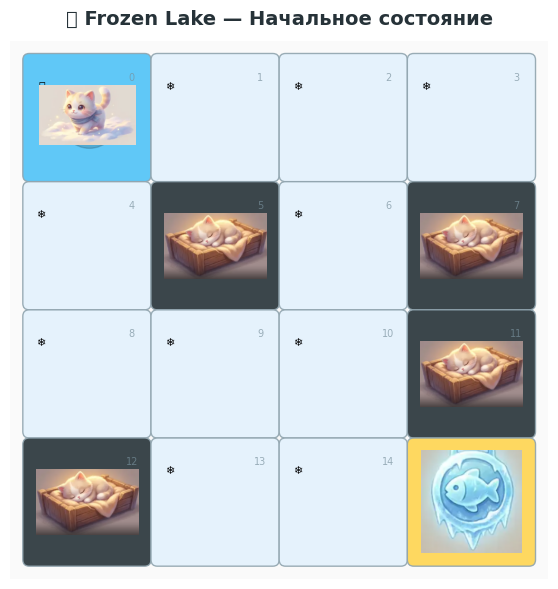

In [4]:
# Custom render_lake method with Base64 Images
import base64
from io import BytesIO
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, Circle
import numpy as np

agent_b64 = "..."
goal_b64 = "..."
hole_b64 = "..."

TILE_INFO = {
    b'S': {'color': '#4FC3F7', 'emoji': '🏁', 'label': 'Старт'},
    b'F': {'color': '#E3F2FD', 'emoji': '❄️',  'label': 'Лёд'},
    b'H': {'color': '#263238', 'emoji': '', 'label': 'Прорубь'},
    b'G': {'color': '#FFD54F', 'emoji': '', 'label': 'Цель'},
}
ACTION_ARROWS = {0: '←', 1: '↓', 2: '→', 3: '↑'}

def draw_image(ax, b64_string, x, y, size=0.8, zorder=5):
    import PIL.Image
    img_data = base64.b64decode(b64_string)
    img = PIL.Image.open(BytesIO(img_data))
    if img.mode != 'RGBA':
        img = img.convert('RGBA')
    w, h = img.size
    aspect = w / h
    if aspect > 1:
        rw = size
        rh = size / aspect
    else:
        rh = size
        rw = size * aspect
    extent = [x - rw/2, x + rw/2, y + rh/2, y - rh/2]
    ax.imshow(img, extent=extent, zorder=zorder)

def render_lake(env, agent_pos, title="Frozen Lake", q_table=None, highlight_path=None, ax=None):
    desc = env.unwrapped.desc
    nrow, ncol = desc.shape
    created_fig = False
    if ax is None:
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        created_fig = True
    ax.clear()
    ax.set_xlim(-0.1, ncol + 0.1)
    ax.set_ylim(-0.1, nrow + 0.1)
    ax.set_aspect('equal')
    ax.invert_yaxis()
    ax.set_xticks([])
    ax.set_yticks([])
    ax.set_title(title, fontsize=14, fontweight='bold', pad=12, color='#263238')
    ax.set_facecolor('#FAFAFA')
    for r in range(nrow):
        for c in range(ncol):
            cell_type = desc[r][c]
            info = TILE_INFO.get(cell_type, TILE_INFO[b'F'])
            cell_idx = r * ncol + c
            edge_color = '#90A4AE'
            edge_width = 1
            if highlight_path and cell_idx in highlight_path:
                edge_color = '#FF6F00'
                edge_width = 2.5
            rect = FancyBboxPatch((c + 0.05, r + 0.05), 0.9, 0.9, boxstyle="round,pad=0.05", facecolor=info['color'], edgecolor=edge_color, linewidth=edge_width, alpha=0.9)
            ax.add_patch(rect)
            if info.get('emoji'):
                ax.text(c + 0.15, r + 0.25, info['emoji'], fontsize=8, ha='center', va='center')
            if cell_type == b'G':
                draw_image(ax, goal_b64, c + 0.5, r + 0.5, size=0.8, zorder=5)
            elif cell_type == b'H':
                draw_image(ax, hole_b64, c + 0.5, r + 0.5, size=0.8, zorder=5)
            ax.text(c + 0.85, r + 0.18, str(cell_idx), fontsize=7, ha='center', va='center', color='#78909C', alpha=0.7)
            if q_table is not None and cell_type not in (b'H', b'G'):
                best_action = np.argmax(q_table[cell_idx])
                if np.max(q_table[cell_idx]) > 0:
                    ax.text(c + 0.5, r + 0.72, ACTION_ARROWS[best_action], fontsize=16, ha='center', va='center', color='#1565C0', fontweight='bold', alpha=0.8)
    agent_r = agent_pos // ncol
    agent_c = agent_pos % ncol
    shadow = Circle((agent_c + 0.52, agent_r + 0.52), 0.22, color='#000000', alpha=0.15)
    ax.add_patch(shadow)
    draw_image(ax, agent_b64, agent_c + 0.5, agent_r + 0.48, size=0.75, zorder=10)
    ax.spines[:].set_visible(False)
    if created_fig:
        plt.tight_layout()
        plt.show()

print("✅ Функция render_lake загружена с графическими ассетами!")
print("   Давайте посмотрим, как выглядит озеро:\n")
import gymnasium as gym
demo_env = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=False)
demo_env.reset()
render_lake(demo_env, agent_pos=0, title="🧊 Frozen Lake — Начальное состояние")
demo_env.close()




# 5. 🏗️ Инициализация среды и Q-таблицы

Теперь создадим среду и пустую Q-таблицу, которую агент будет заполнять в процессе обучения.

### 📋 Гиперпараметры

| Параметр | Обозначение | Значение | Зачем |
|----------|-------------|----------|-------|
| Кол-во эпизодов | `n_episodes` | 2000 | Сколько раз агент пройдёт игру от начала до конца |
| Макс. шагов | `max_steps` | 100 | Максимум шагов в одном эпизоде |
| Скорость обучения | $\alpha$ | 0.8 | Как быстро обновлять Q-значения |
| Дисконтирование | $\gamma$ | 0.95 | Важность будущих наград |
| Начальный ε | $\varepsilon_{\max}$ | 1.0 | Старт: 100% случайных действий |
| Финальный ε | $\varepsilon_{\min}$ | 0.01 | Финиш: почти всегда лучшее действие |
| Скорость затухания ε | `decay_rate` | 0.001 | Как быстро снижается ε |


In [5]:
# ═══════════════════════════════════════════════════════════════
# 🏗️ ИНИЦИАЛИЗАЦИЯ СРЕДЫ И ПАРАМЕТРОВ
# ═══════════════════════════════════════════════════════════════

# ── 1. Создаём среду ──
env = gym.make(
    'FrozenLake-v1',     # Название среды
    map_name='4x4',       # Карта 4×4
    is_slippery=False,    # Лёд НЕ скользкий (для наглядности)
    # Попробуйте позже: is_slippery=True
)

# ── 2. Размеры пространств ──
n_states  = env.observation_space.n   # 16 состояний (клеток)
n_actions = env.action_space.n        # 4 действия (←↓→↑)

print("┌─────────────────────────────────────────┐")
print("│  🏗️  ПАРАМЕТРЫ СРЕДЫ                    │")
print("│  ─────────────────────────────────────── │")
print(f"│  Состояний : {n_states:>3d}  (клетки 4×4)         │")
print(f"│  Действий  : {n_actions:>3d}  (← ↓ → ↑)           │")
print(f"│  Скользко  : {'Да' if env.unwrapped.spec and 'slippery' in str(env.unwrapped.spec) else 'Нет':>3s}                          │")
print("└─────────────────────────────────────────┘")

# ── 3. Гиперпараметры Q-Learning ──
n_episodes  = 2000     # Количество эпизодов обучения
max_steps   = 100      # Максимум шагов в эпизоде

alpha       = 0.8      # Скорость обучения (learning rate)
gamma       = 0.95     # Коэффициент дисконтирования (discount factor)

epsilon_max   = 1.0    # Начальное значение ε
epsilon_min   = 0.01   # Минимальное значение ε
decay_rate    = 0.001  # Скорость затухания ε

# ── 4. Создаём Q-таблицу (все нули) ──
q_table = np.zeros((n_states, n_actions))

print(f"\n📋 Q-таблица создана: {q_table.shape[0]} строк × {q_table.shape[1]} столбцов")
print(f"   Все значения = 0.00 (агент ещё ничего не знает)\n")

# Показываем начальную Q-таблицу
print("   Начальная Q-таблица:")
print("   ──────────────────────────────────────")
print("   Состояние │  ← Влево  │  ↓ Вниз  │  → Вправо │  ↑ Вверх")
print("   ──────────────────────────────────────")
for s in range(min(5, n_states)):
    vals = "  │  ".join([f"{q_table[s,a]:7.4f}" for a in range(n_actions)])
    print(f"       {s:>2d}    │  {vals}")
print("       ...   │    ...    │    ...    │    ...     │    ...")
print("   ──────────────────────────────────────")


┌─────────────────────────────────────────┐
│  🏗️  ПАРАМЕТРЫ СРЕДЫ                    │
│  ─────────────────────────────────────── │
│  Состояний :  16  (клетки 4×4)         │
│  Действий  :   4  (← ↓ → ↑)           │
│  Скользко  :  Да                          │
└─────────────────────────────────────────┘

📋 Q-таблица создана: 16 строк × 4 столбцов
   Все значения = 0.00 (агент ещё ничего не знает)

   Начальная Q-таблица:
   ──────────────────────────────────────
   Состояние │  ← Влево  │  ↓ Вниз  │  → Вправо │  ↑ Вверх
   ──────────────────────────────────────
        0    │   0.0000  │   0.0000  │   0.0000  │   0.0000
        1    │   0.0000  │   0.0000  │   0.0000  │   0.0000
        2    │   0.0000  │   0.0000  │   0.0000  │   0.0000
        3    │   0.0000  │   0.0000  │   0.0000  │   0.0000
        4    │   0.0000  │   0.0000  │   0.0000  │   0.0000
       ...   │    ...    │    ...    │    ...     │    ...
   ──────────────────────────────────────



# 6. 🏋️ Обучение агента (Q-Learning)

Теперь запустим обучение! Ниже реализован полный алгоритм Q-Learning.

### 🔄 Что происходит на каждом эпизоде:

1. Агент стартует в клетке **S** (позиция 0)
2. Выбирает действие по стратегии **ε-greedy**
3. Выполняет действие → получает **новое состояние** и **награду**
4. **Обновляет Q-таблицу** по уравнению Беллмана
5. Повторяет, пока не дойдёт до цели (G) или не провалится (H)

> ⚡ **Визуализация**: Каждые 500 эпизодов будет отображаться текущий прогресс обучения, включая живую визуализацию одного эпизода.


In [6]:
# ═══════════════════════════════════════════════════════════════
# 🏋️ ЦИКЛ ОБУЧЕНИЯ Q-LEARNING
# ═══════════════════════════════════════════════════════════════

# Списки для сохранения метрик
rewards_per_episode = []      # Награда за каждый эпизод (0 или 1)
steps_per_episode = []        # Количество шагов в каждом эпизоде
epsilon_history = []          # История значений ε

# Моменты, когда показываем визуализацию
visual_checkpoints = [0, 499, 999, 1499, 1999]

print("┌─────────────────────────────────────────────────┐")
print("│  🏋️  НАЧАЛО ОБУЧЕНИЯ Q-LEARNING                 │")
print("│  ═══════════════════════════════════════════════ │")
print(f"│  Эпизодов: {n_episodes}  │  α={alpha}  │  γ={gamma}           │")
print(f"│  ε: {epsilon_max} → {epsilon_min}  │  decay={decay_rate}             │")
print("└─────────────────────────────────────────────────┘\n")

start_time = time.time()

for episode in range(n_episodes):
    # ── Сброс среды ──
    state, info = env.reset()
    total_reward = 0
    done = False
    truncated = False
    path = [state]  # Запоминаем путь агента
    
    # ── Вычисляем текущий ε ──
    # Формула: ε = ε_min + (ε_max - ε_min) × exp(-decay_rate × episode)
    epsilon = epsilon_min + (epsilon_max - epsilon_min) * np.exp(-decay_rate * episode)
    epsilon_history.append(epsilon)
    
    for step in range(max_steps):
        # ── 1. Выбор действия (ε-greedy) ──
        if np.random.random() < epsilon:
            # ИССЛЕДОВАНИЕ: случайное действие
            action = env.action_space.sample()
        else:
            # ИСПОЛЬЗОВАНИЕ: лучшее действие по Q-таблице
            action = np.argmax(q_table[state])
        
        # ── 2. Выполняем действие ──
        new_state, reward, done, truncated, info = env.step(action)
        path.append(new_state)
        
        # ── 3. Обновляем Q-таблицу (уравнение Беллмана!) ──
        # Q(s,a) ← Q(s,a) + α × [ r + γ × max Q(s',a') - Q(s,a) ]
        td_target = reward + gamma * np.max(q_table[new_state]) * (1 - done)
        td_error  = td_target - q_table[state, action]
        q_table[state, action] += alpha * td_error
        
        # ── 4. Переходим в новое состояние ──
        total_reward += reward
        state = new_state
        
        if done or truncated:
            break
    
    # Сохраняем метрики
    rewards_per_episode.append(total_reward)
    steps_per_episode.append(step + 1)
    
    # ── Визуализация прогресса ──
    if episode in visual_checkpoints:
        clear_output(wait=True)
        
        # Вычисляем статистику
        window = min(100, episode + 1)
        recent_rewards = rewards_per_episode[-window:]
        win_rate = sum(recent_rewards) / len(recent_rewards) * 100
        
        # Ретро-терминальный лог
        elapsed = time.time() - start_time
        print(f"╔══════════════════════════════════════════════════╗")
        print(f"║  📡 ОБУЧЕНИЕ │ Эпизод {episode+1:>5d}/{n_episodes}              ║")
        print(f"╠══════════════════════════════════════════════════╣")
        print(f"║  ε (исследование) : {epsilon:>8.4f}                    ║")
        print(f"║  Побед (100 посл.): {win_rate:>7.1f}%                    ║")
        print(f"║  Время обучения   : {elapsed:>7.2f} сек                 ║")
        
        # Прогресс-бар
        progress = (episode + 1) / n_episodes
        bar_len = 30
        filled = int(bar_len * progress)
        bar = '█' * filled + '░' * (bar_len - filled)
        print(f"║  Прогресс: [{bar}] {progress*100:.0f}%   ║")
        print(f"╚══════════════════════════════════════════════════╝\n")
        
        # Визуализация: показываем Q-таблицу на поле
        fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
        
        # Левый: поле с текущим путём агента
        render_lake(env, agent_pos=path[-1],
                   title=f"Эпизод {episode+1}: путь агента ({len(path)} шагов)",
                   q_table=q_table, highlight_path=path, ax=axes[0])
        
        # Правый: кривая обучения
        ax2 = axes[1]
        if len(rewards_per_episode) >= 50:
            # Скользящее среднее
            window_size = 50
            moving_avg = np.convolve(
                rewards_per_episode, 
                np.ones(window_size)/window_size, 
                mode='valid'
            )
            ax2.plot(moving_avg, color='#00BCD4', linewidth=2, label='Скользящее среднее (50)')
            ax2.fill_between(range(len(moving_avg)), moving_avg, alpha=0.15, color='#00BCD4')
        
        ax2.set_xlabel('Эпизод', fontsize=11)
        ax2.set_ylabel('Средняя награда', fontsize=11)
        ax2.set_title('📈 Кривая обучения', fontsize=13, fontweight='bold')
        ax2.set_ylim(-0.05, 1.05)
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3)
        ax2.set_facecolor('#FAFAFA')
        
        plt.tight_layout()
        plt.show()

# ── Финальный отчёт ──
clear_output(wait=True)
total_time = time.time() - start_time

final_win_rate = sum(rewards_per_episode[-100:]) / 100 * 100

print("╔══════════════════════════════════════════════════╗")
print("║            ✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!                ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Всего эпизодов   : {n_episodes:>6d}                      ║")
print(f"║  Время обучения   : {total_time:>7.2f} сек                 ║")
print(f"║  Финальный ε      : {epsilon:>8.5f}                   ║")
print(f"║  Побед (последние 100): {final_win_rate:>5.1f}%                ║")
print("╠══════════════════════════════════════════════════╣")
print("║  ➡️  Переходим к анализу результатов...          ║")
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║            ✅ ОБУЧЕНИЕ ЗАВЕРШЕНО!                ║
╠══════════════════════════════════════════════════╣
║  Всего эпизодов   :   2000                      ║
║  Время обучения   :    3.50 сек                 ║
║  Финальный ε      :  0.14412                   ║
║  Побед (последние 100):  89.0%                ║
╠══════════════════════════════════════════════════╣
║  ➡️  Переходим к анализу результатов...          ║
╚══════════════════════════════════════════════════╝



# 7. 📊 Анализ результатов обучения

Теперь посмотрим, чему научился наш агент. Построим графики метрик и **тепловую карту Q-таблицы**.


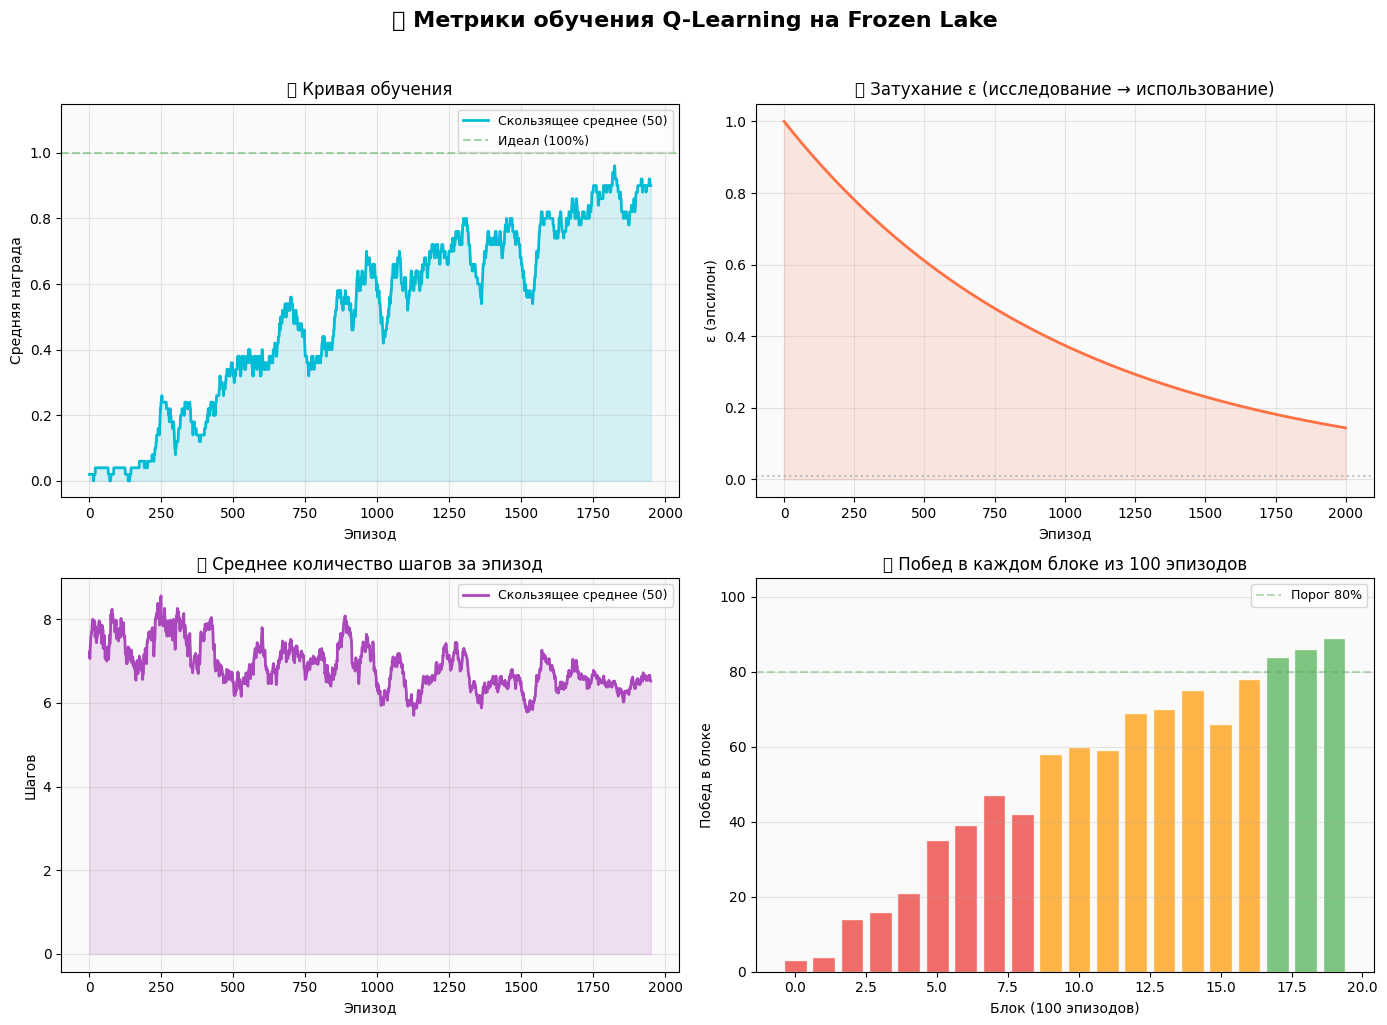

In [7]:
# ═══════════════════════════════════════════════════════════════
# 📊 ГРАФИКИ МЕТРИК ОБУЧЕНИЯ
# ═══════════════════════════════════════════════════════════════

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('📊 Метрики обучения Q-Learning на Frozen Lake', 
             fontsize=16, fontweight='bold', y=1.02)

# ── 1. Кривая обучения (награда) ──
ax1 = axes[0, 0]
window_size = 50
moving_avg = np.convolve(rewards_per_episode, 
                          np.ones(window_size)/window_size, mode='valid')
ax1.plot(moving_avg, color='#00BCD4', linewidth=2, label='Скользящее среднее (50)')
ax1.fill_between(range(len(moving_avg)), moving_avg, alpha=0.15, color='#00BCD4')
ax1.axhline(y=1.0, color='#4CAF50', linestyle='--', alpha=0.5, label='Идеал (100%)')
ax1.set_xlabel('Эпизод')
ax1.set_ylabel('Средняя награда')
ax1.set_title('📈 Кривая обучения')
ax1.set_ylim(-0.05, 1.15)
ax1.legend(fontsize=9)
ax1.grid(True, alpha=0.3)
ax1.set_facecolor('#FAFAFA')

# ── 2. Затухание ε ──
ax2 = axes[0, 1]
ax2.plot(epsilon_history, color='#FF7043', linewidth=2)
ax2.fill_between(range(len(epsilon_history)), epsilon_history, alpha=0.15, color='#FF7043')
ax2.axhline(y=epsilon_min, color='#78909C', linestyle=':', alpha=0.5)
ax2.set_xlabel('Эпизод')
ax2.set_ylabel('ε (эпсилон)')
ax2.set_title('🎲 Затухание ε (исследование → использование)')
ax2.set_facecolor('#FAFAFA')
ax2.grid(True, alpha=0.3)

# ── 3. Количество шагов за эпизод ──
ax3 = axes[1, 0]
steps_avg = np.convolve(steps_per_episode, 
                         np.ones(window_size)/window_size, mode='valid')
ax3.plot(steps_avg, color='#AB47BC', linewidth=2, label='Скользящее среднее (50)')
ax3.fill_between(range(len(steps_avg)), steps_avg, alpha=0.15, color='#AB47BC')
ax3.set_xlabel('Эпизод')
ax3.set_ylabel('Шагов')
ax3.set_title('👣 Среднее количество шагов за эпизод')
ax3.legend(fontsize=9)
ax3.grid(True, alpha=0.3)
ax3.set_facecolor('#FAFAFA')

# ── 4. Распределение побед по блокам ──
ax4 = axes[1, 1]
block_size = 100
n_blocks = len(rewards_per_episode) // block_size
block_wins = [sum(rewards_per_episode[i*block_size:(i+1)*block_size]) 
              for i in range(n_blocks)]
colors = ['#EF5350' if w < 50 else '#FFA726' if w < 80 else '#66BB6A' for w in block_wins]
ax4.bar(range(n_blocks), block_wins, color=colors, alpha=0.85, edgecolor='white')
ax4.set_xlabel(f'Блок ({block_size} эпизодов)')
ax4.set_ylabel('Побед в блоке')
ax4.set_title('🏆 Побед в каждом блоке из 100 эпизодов')
ax4.set_ylim(0, 105)
ax4.axhline(y=80, color='#4CAF50', linestyle='--', alpha=0.4, label='Порог 80%')
ax4.legend(fontsize=9)
ax4.grid(True, alpha=0.3, axis='y')
ax4.set_facecolor('#FAFAFA')

plt.tight_layout()
plt.show()



### 🔥 Тепловая карта Q-таблицы

Тепловая карта показывает **лучшее Q-значение** в каждой клетке (т.е. $\max_a Q(s,a)$).  
Чем ярче клетка — тем ближе она к цели по мнению агента.


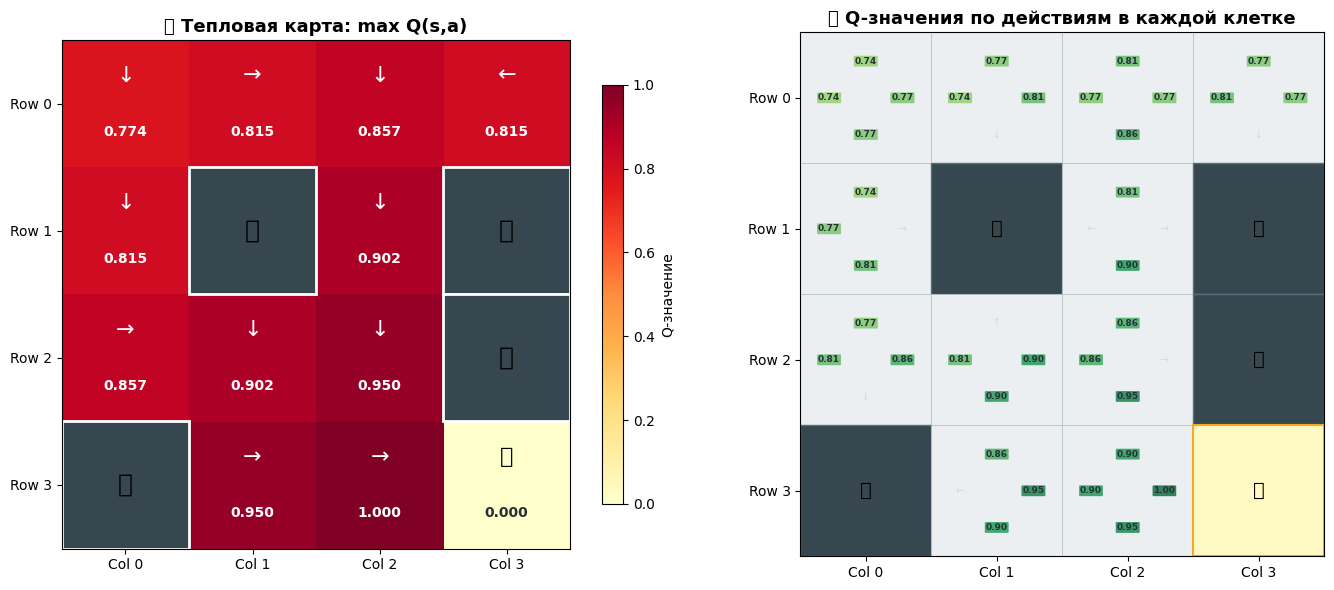


📋 Обученная Q-таблица:
──────────────────────────────────────────────────────────────────────
  Сост. │   ← Влево │    ↓ Вниз │  → Вправо │   ↑ Вверх │ Лучшее
──────────────────────────────────────────────────────────────────────
      0 │    0.7351  │     0.7738  │     0.7738  │     0.7351 │ Вниз
      1 │    0.7351  │     0.0000  │     0.8145  │     0.7738 │ Вправо
      2 │    0.7738  │     0.8574  │     0.7738  │     0.8145 │ Вниз
      3 │    0.8145  │     0.0000  │     0.7738  │     0.7738 │ Влево
      4 │    0.7738  │     0.8145  │     0.0000  │     0.7351 │ Вниз
      5 │    0.0000  │     0.0000  │     0.0000  │     0.0000 │ — 🕳️
      6 │    0.0000  │     0.9025  │     0.0000  │     0.8145 │ Вниз
      7 │    0.0000  │     0.0000  │     0.0000  │     0.0000 │ — 🕳️
      8 │    0.8145  │     0.0000  │     0.8574  │     0.7738 │ Вправо
      9 │    0.8145  │     0.9025  │     0.9025  │     0.0000 │ Вниз
     10 │    0.8574  │     0.9500  │     0.0000  │     0.8574 │ Вниз
     

In [8]:
# ═══════════════════════════════════════════════════════════════
# 🔥 ТЕПЛОВАЯ КАРТА Q-ТАБЛИЦЫ ПОВЕРХ СЕТКИ ОЗЕРА
# ═══════════════════════════════════════════════════════════════

desc = env.unwrapped.desc
nrow, ncol = desc.shape

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Левая часть: Тепловая карта max Q-значений ──
ax1 = axes[0]

# Собираем матрицу max Q-значений
max_q = np.max(q_table, axis=1).reshape(nrow, ncol)

# Отмечаем проруби как NaN для отдельной окраски
mask_holes = np.zeros_like(max_q, dtype=bool)
for r in range(nrow):
    for c in range(ncol):
        if desc[r][c] == b'H':
            mask_holes[r, c] = True

# Рисуем тепловую карту
im = ax1.imshow(np.where(mask_holes, np.nan, max_q), 
                cmap='YlOrRd', interpolation='nearest',
                vmin=0, vmax=1.0)

# Проруби — серым
for r in range(nrow):
    for c in range(ncol):
        if mask_holes[r, c]:
            ax1.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, 
                          facecolor='#37474F', edgecolor='white', linewidth=2))
            ax1.text(c, r, '🕳️', ha='center', va='center', fontsize=18)
        else:
            # Значение max Q
            val = max_q[r, c]
            color = 'white' if val > 0.5 else '#263238'
            ax1.text(c, r + 0.22, f'{val:.3f}', ha='center', va='center', 
                    fontsize=10, fontweight='bold', color=color)
            # Лучшее действие
            s = r * ncol + c
            if np.max(q_table[s]) > 0 and desc[r][c] != b'G':
                best_a = np.argmax(q_table[s])
                ax1.text(c, r - 0.22, ACTION_ARROWS[best_a], 
                        ha='center', va='center', fontsize=16, color=color)

# Цель
goal_r, goal_c = np.where(desc == b'G')
if len(goal_r) > 0:
    ax1.text(goal_c[0], goal_r[0] - 0.22, '🎁', ha='center', va='center', fontsize=16)

ax1.set_xticks(range(ncol))
ax1.set_yticks(range(nrow))
ax1.set_xticklabels([f'Col {c}' for c in range(ncol)])
ax1.set_yticklabels([f'Row {r}' for r in range(nrow)])
ax1.set_title('🔥 Тепловая карта: max Q(s,a)', fontsize=13, fontweight='bold')
plt.colorbar(im, ax=ax1, shrink=0.8, label='Q-значение')

# ── Правая часть: Q-значения для каждого действия ──
ax2 = axes[1]

# Для каждой клетки рисуем 4 мини-стрелки с цветовой кодировкой
ax2.set_xlim(-0.5, ncol - 0.5)
ax2.set_ylim(-0.5, nrow - 0.5)
ax2.invert_yaxis()
ax2.set_aspect('equal')

# Цветовая шкала для Q-значений
norm = plt.Normalize(vmin=0, vmax=max(np.max(q_table), 0.01))
cmap = plt.cm.RdYlGn

for r in range(nrow):
    for c in range(ncol):
        s = r * ncol + c
        cell_type = desc[r][c]
        
        # Фон клетки
        if cell_type == b'H':
            ax2.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, 
                          facecolor='#37474F', edgecolor='#546E7A', linewidth=1))
            ax2.text(c, r, '🕳️', ha='center', va='center', fontsize=14)
            continue
        elif cell_type == b'G':
            ax2.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, 
                          facecolor='#FFF9C4', edgecolor='#F9A825', linewidth=1.5))
            ax2.text(c, r, '🎁', ha='center', va='center', fontsize=14)
            continue
        else:
            ax2.add_patch(plt.Rectangle((c-0.5, r-0.5), 1, 1, 
                          facecolor='#ECEFF1', edgecolor='#B0BEC5', linewidth=0.5))
        
        # 4 стрелки-значения
        # ← Влево (0), ↓ Вниз (1), → Вправо (2), ↑ Вверх (3)
        positions = {
            0: (c - 0.28, r),      # Влево
            1: (c, r + 0.28),      # Вниз
            2: (c + 0.28, r),      # Вправо
            3: (c, r - 0.28),      # Вверх
        }
        
        for a in range(4):
            q_val = q_table[s, a]
            px, py = positions[a]
            
            if q_val > 0.001:
                color = cmap(norm(q_val))
                ax2.text(px, py, f'{q_val:.2f}', ha='center', va='center',
                        fontsize=6.5, fontweight='bold', color='#263238',
                        bbox=dict(boxstyle='round,pad=0.1', facecolor=color, 
                                 edgecolor='none', alpha=0.8))
            else:
                ax2.text(px, py, ACTION_ARROWS[a], ha='center', va='center',
                        fontsize=8, color='#B0BEC5', alpha=0.4)

ax2.set_xticks(range(ncol))
ax2.set_yticks(range(nrow))
ax2.set_xticklabels([f'Col {c}' for c in range(ncol)])
ax2.set_yticklabels([f'Row {r}' for r in range(nrow)])
ax2.set_title('🧭 Q-значения по действиям в каждой клетке', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.show()

# ── Вывод обученной Q-таблицы ──
print("\n📋 Обученная Q-таблица:")
print("─" * 70)
print(f"  {'Сост.':>5s} │ {'← Влево':>9s} │ {'↓ Вниз':>9s} │ {'→ Вправо':>9s} │ {'↑ Вверх':>9s} │ Лучшее")
print("─" * 70)
for s in range(n_states):
    vals = [f"{q_table[s,a]:>9.4f}" for a in range(n_actions)]
    best = ACTION_NAMES[np.argmax(q_table[s])] if np.max(q_table[s]) > 0 else "—"
    cell_type = desc[s // ncol][s % ncol]
    marker = " 🕳️" if cell_type == b'H' else " 🎁" if cell_type == b'G' else ""
    print(f"  {s:>5d} │ {'  │  '.join(vals)} │ {best}{marker}")
print("─" * 70)



# 8. 🎮 Тестирование обученного агента

Теперь самое интересное — **смотрим, как агент проходит озеро!**

Агент будет использовать обученную Q-таблицу (всегда выбирать лучшее действие, без случайных ходов).

> 🔄 **Анимация**: вы увидите каждый шаг агента с паузой, чтобы можно было проследить за его передвижением по озеру.


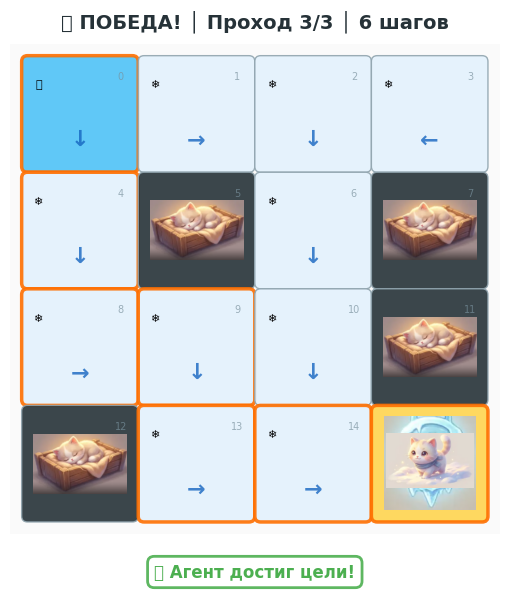


  📍 Путь агента: 0 → 4 → 8 → 9 → 13 → 14 → 15
  🎯 Действия:    ↓ → ↓ → → → ↓ → → → →
  📊 Награда:     1.0

══════════════════════════════════════════════════
  🏁 Итого: 3/3 побед (100%)
══════════════════════════════════════════════════


In [9]:
# ═══════════════════════════════════════════════════════════════
# 🎮 ТЕСТИРОВАНИЕ: ЖИВАЯ АНИМАЦИЯ АГЕНТА
# ═══════════════════════════════════════════════════════════════

def run_agent_animated(env, q_table, delay=0.6, run_label="Тест"):
    '''
    Запускает агента и показывает каждый шаг с анимацией.
    
    Параметры:
    ----------
    env       : среда gymnasium
    q_table   : обученная Q-таблица
    delay     : пауза между шагами (секунды)
    run_label : метка для заголовка
    '''
    state, info = env.reset()
    done = False
    truncated = False
    path = [state]
    actions_taken = []
    total_reward = 0
    step_count = 0
    
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    while not done and not truncated and step_count < max_steps:
        clear_output(wait=True)
        
        # Выбираем лучшее действие из Q-таблицы (жадная стратегия)
        action = np.argmax(q_table[state])
        actions_taken.append(action)
        
        # Выполняем действие
        new_state, reward, done, truncated, info = env.step(action)
        total_reward += reward
        step_count += 1
        path.append(new_state)
        
        # Отображаем
        fig, ax = plt.subplots(1, 1, figsize=(6, 6))
        render_lake(
            env, 
            agent_pos=new_state, 
            title=f"🎮 {run_label} │ Шаг {step_count}: {ACTION_NAMES[action]}",
            q_table=q_table,
            highlight_path=path,
            ax=ax
        )
        
        # Лог хода в стиле терминала
        desc = env.unwrapped.desc
        nr, nc = desc.shape
        cell_r, cell_c = new_state // nc, new_state % nc
        cell_type = desc[cell_r][cell_c]
        cell_info = TILE_INFO.get(cell_type, TILE_INFO[b'F'])
        
        log_text = (f"  ▸ Шаг {step_count}: состояние {state} "
                    f"─{ACTION_ARROWS[action]}─▸ состояние {new_state} "
                    f"({cell_info['emoji']} {cell_info['label']})  │  r = {reward}")
        
        ax.text(0.5, -0.06, log_text, transform=ax.transAxes,
                fontsize=9, ha='center', va='top',
                fontfamily='monospace', color='#37474F',
                bbox=dict(boxstyle='round,pad=0.4', facecolor='#ECEFF1', 
                         edgecolor='#B0BEC5', alpha=0.9))
        
        plt.tight_layout()
        plt.show()
        time.sleep(delay)
        plt.close(fig)
        
        state = new_state
    
    # ── Финальный кадр ──
    clear_output(wait=True)
    fig, ax = plt.subplots(1, 1, figsize=(6, 6))
    
    if total_reward > 0:
        final_title = f"🏆 ПОБЕДА! │ {run_label} │ {step_count} шагов"
        result_color = '#4CAF50'
        result_text = "✅ Агент достиг цели!"
    else:
        final_title = f"💀 Провал │ {run_label} │ {step_count} шагов"
        result_color = '#EF5350'
        result_text = "❌ Агент провалился в прорубь"
    
    render_lake(env, agent_pos=state, title=final_title,
               q_table=q_table, highlight_path=path, ax=ax)
    
    ax.text(0.5, -0.06, result_text, transform=ax.transAxes,
            fontsize=12, ha='center', va='top', fontweight='bold',
            color=result_color,
            bbox=dict(boxstyle='round,pad=0.4', facecolor='white', 
                     edgecolor=result_color, alpha=0.9, linewidth=2))
    
    plt.tight_layout()
    plt.show()
    
    # Вывод пути
    path_str = " → ".join([str(p) for p in path])
    print(f"\n  📍 Путь агента: {path_str}")
    actions_str = " → ".join([ACTION_ARROWS[a] for a in actions_taken])
    print(f"  🎯 Действия:    {actions_str}")
    print(f"  📊 Награда:     {total_reward}")
    
    return total_reward, path


# ── Запускаем 3 тестовых прохода ──
print("╔══════════════════════════════════════════════════╗")
print("║  🎮 ТЕСТИРОВАНИЕ ОБУЧЕННОГО АГЕНТА              ║")
print("║  Агент использует Q-таблицу (ε = 0, без случ.)  ║")
print("╚══════════════════════════════════════════════════╝\n")
print("  ▸ Запуск прохода 1 из 3...\n")
time.sleep(1)

results = []
for run in range(3):
    reward, path = run_agent_animated(env, q_table, delay=0.5, 
                                       run_label=f"Проход {run+1}/3")
    results.append(reward)
    if run < 2:
        time.sleep(1)
        clear_output(wait=True)
        print(f"  ▸ Запуск прохода {run+2} из 3...\n")
        time.sleep(0.5)

# Итоговая статистика
print(f"\n{'═'*50}")
print(f"  🏁 Итого: {sum(results):.0f}/3 побед ({sum(results)/3*100:.0f}%)")
print(f"{'═'*50}")



### 📊 Массовое тестирование

Запустим агента **1000 раз** (без визуализации), чтобы точно измерить процент побед.


In [10]:
# ═══════════════════════════════════════════════════════════════
# 📊 МАССОВОЕ ТЕСТИРОВАНИЕ (1000 ЭПИЗОДОВ)
# ═══════════════════════════════════════════════════════════════

n_test = 1000
test_wins = 0
test_steps_list = []

for _ in range(n_test):
    state, _ = env.reset()
    done = False
    truncated = False
    steps = 0
    
    while not done and not truncated and steps < max_steps:
        action = np.argmax(q_table[state])
        state, reward, done, truncated, _ = env.step(action)
        steps += 1
        if reward > 0:
            test_wins += 1
    
    test_steps_list.append(steps)

win_pct = test_wins / n_test * 100
avg_steps = np.mean(test_steps_list)

print("╔══════════════════════════════════════════════════╗")
print("║  📊 РЕЗУЛЬТАТЫ МАССОВОГО ТЕСТИРОВАНИЯ           ║")
print("╠══════════════════════════════════════════════════╣")
print(f"║  Тестовых эпизодов : {n_test:>6d}                     ║")
print(f"║  Побед             : {test_wins:>6d}                     ║")
print(f"║  Процент побед     : {win_pct:>6.1f}%                    ║")
print(f"║  Средн. шагов      : {avg_steps:>6.1f}                     ║")
print("╠══════════════════════════════════════════════════╣")

if win_pct >= 95:
    print("║  🌟 Отличный результат! Агент обучен превосходно ║")
elif win_pct >= 70:
    print("║  ✅ Хороший результат. Агент справляется!        ║")
else:
    print("║  ⚠️  Попробуйте увеличить n_episodes или α       ║")
    
print("╚══════════════════════════════════════════════════╝")


╔══════════════════════════════════════════════════╗
║  📊 РЕЗУЛЬТАТЫ МАССОВОГО ТЕСТИРОВАНИЯ           ║
╠══════════════════════════════════════════════════╣
║  Тестовых эпизодов :   1000                     ║
║  Побед             :   1000                     ║
║  Процент побед     :  100.0%                    ║
║  Средн. шагов      :    6.0                     ║
╠══════════════════════════════════════════════════╣
║  🌟 Отличный результат! Агент обучен превосходно ║
╚══════════════════════════════════════════════════╝



# 9. 🧪 Эксперименты: попробуйте сами!

Обучение с подкреплением — это экспериментальная наука. Попробуйте изменить параметры и посмотрите, что произойдёт!

### 🔧 Что можно менять:

| Что изменить | Где в коде | Ожидаемый эффект |
|-------------|------------|------------------|
| Включить скольжение | `is_slippery=True` | Задача станет **намного сложнее**! Понадобится больше эпизодов |
| Увеличить обучение | `n_episodes = 10000` | Агент будет учиться дольше, но точнее |
| Уменьшить α | `alpha = 0.1` | Более плавное, но медленное обучение |
| Уменьшить γ | `gamma = 0.5` | Агент будет «близорук» — не думает о будущем |
| Быстрое затухание ε | `decay_rate = 0.01` | Быстрый переход от исследования к использованию |

---

### 🧊 Эксперимент: скользкий лёд

Раскомментируйте и запустите ячейку ниже, чтобы обучить агента на **скользком** озере:


In [ ]:
# ═══════════════════════════════════════════════════════════════
# 🧪 ЭКСПЕРИМЕНТ: СКОЛЬЗКИЙ ЛЁД
# ═══════════════════════════════════════════════════════════════
# Раскомментируйте код ниже и запустите ячейку (Shift+Enter)

# # Создаём скользкую среду
# env_slippery = gym.make('FrozenLake-v1', map_name='4x4', is_slippery=True)
# 
# # Новые параметры (нужно больше обучения!)
# q_table_slip = np.zeros((16, 4))
# n_ep_slip = 20000     # Гораздо больше эпизодов!
# alpha_slip = 0.1      # Меньше скорость обучения
# gamma_slip = 0.99     # Больше «терпения»
# 
# rewards_slip = []
# 
# for ep in range(n_ep_slip):
#     state, _ = env_slippery.reset()
#     eps = max(0.01, 1.0 * np.exp(-0.0005 * ep))
#     done = False
#     
#     for _ in range(200):
#         if np.random.random() < eps:
#             action = env_slippery.action_space.sample()
#         else:
#             action = np.argmax(q_table_slip[state])
#         
#         ns, r, done, trunc, _ = env_slippery.step(action)
#         q_table_slip[state, action] += alpha_slip * (
#             r + gamma_slip * np.max(q_table_slip[ns]) * (1 - done) 
#             - q_table_slip[state, action]
#         )
#         state = ns
#         if done or trunc:
#             break
#     
#     rewards_slip.append(r)
# 
# # Результат
# win_rate = sum(rewards_slip[-1000:]) / 1000 * 100
# print(f"🧊 Скользкий лёд: {win_rate:.1f}% побед (последние 1000 эпизодов)")
# print("   (типичный результат: 70-80% — отлично для скользкого льда!)")
# 
# # Визуализация
# render_lake(env_slippery, agent_pos=0, 
#            title="🧊 Q-таблица (скользкий лёд)", q_table=q_table_slip)
# env_slippery.close()

print("ℹ️  Раскомментируйте код выше и запустите для эксперимента со скользким льдом")



---

# 📝 Итоги модуля

### Что мы изучили:

| Тема | Ключевые идеи |
|------|--------------|
| **Обучение с подкреплением** | Агент учится через взаимодействие со средой, получая награды |
| **Q-таблица** | Таблица «выгодности» каждого действия в каждом состоянии |
| **Уравнение Беллмана** | $Q(s,a) \leftarrow Q(s,a) + \alpha [r + \gamma \max Q(s',a') - Q(s,a)]$ |
| **ε-greedy стратегия** | Баланс между исследованием и использованием |
| **Frozen Lake** | Классическая тестовая среда для алгоритмов RL |

### 🚀 Что дальше?

1. **Deep Q-Network (DQN)** — когда состояний слишком много для таблицы, используют нейросеть
2. **Policy Gradient (REINFORCE)** — агент напрямую учит стратегию, а не Q-значения
3. **PPO** — современный алгоритм, используемый в Unity ML-Agents

---

<div style="
  text-align: center;
  padding: 20px;
  background: linear-gradient(135deg, #0f0c29 0%, #302b63 50%, #24243e 100%);
  border-radius: 12px;
  color: #a0a0d0;
  margin-top: 20px;
">
  <p style="font-size: 1.2em; color: #00d4ff;">🧊 Frozen Lake × Q-Learning</p>
  <p>Модуль разработан для платформы <strong style="color: #FFD54F;">CyberUnity Code</strong></p>
  <p style="font-size: 0.85em;">neon-unity-neural · 2025</p>
</div>


In [11]:
# ═══════════════════════════════════════════════════════════════
# 🧹 ОЧИСТКА: закрываем среду
# ═══════════════════════════════════════════════════════════════
env.close()
print("✅ Среда закрыта. Модуль завершён.")
print("   Спасибо за прохождение! 🎉")


✅ Среда закрыта. Модуль завершён.
   Спасибо за прохождение! 🎉
